In [1]:
# Notebook 06 — Classification Model
# Objectives: Train Random Forest classifier to predict flood risk category
# Inputs: outputs/v1/featured_data.csv
# Outputs: outputs/v1/classification_pipeline.pkl

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import joblib
import os

df = pd.read_csv('../outputs/v1/featured_data.csv')
print(f"Shape: {df.shape}")
print(f"Flood risk distribution:\n{df['flood_risk'].value_counts()}")

Shape: (457, 12)
Flood risk distribution:
flood_risk
Medium    348
Low        81
High       28
Name: count, dtype: int64


In [3]:
# Define features and target
features = ['elevation_m', 'distance_to_river_m', 'latitude', 'longitude']
target = 'flood_risk'

X = df[features]
y = df[target]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")

Training set: (365, 4)
Test set: (92, 4)

Training target distribution:
flood_risk
Medium    278
Low        65
High       22
Name: count, dtype: int64


In [4]:
# Build pipeline with scaler and classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 6 hyperparameters with 3+ values each — Distinction criteria D4
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__criterion': ['gini', 'entropy']
}

print("Starting GridSearchCV — this may take a few minutes...")
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Starting GridSearchCV — this may take a few minutes...
Fitting 5 folds for each of 486 candidates, totalling 2430 fits

Best parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__max_features': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
Best cross-validation accuracy: 0.9945


In [5]:
# Evaluate best model on test set
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         6
         Low       1.00      1.00      1.00        16
      Medium       1.00      1.00      1.00        70

    accuracy                           1.00        92
   macro avg       1.00      1.00      1.00        92
weighted avg       1.00      1.00      1.00        92

Confusion Matrix:
[[ 6  0  0]
 [ 0 16  0]
 [ 0  0 70]]


In [6]:
# Save pipeline to outputs/v1/
os.makedirs('../outputs/v1', exist_ok=True)

joblib.dump(best_model, '../outputs/v1/classification_pipeline.pkl')
print("Classification pipeline saved to outputs/v1/classification_pipeline.pkl")
print(f"Best params: {grid_search.best_params_}")

Classification pipeline saved to outputs/v1/classification_pipeline.pkl
Best params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__max_features': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}


Feature Importance:
               feature  importance
0          elevation_m    0.554635
1  distance_to_river_m    0.443804
3            longitude    0.001447
2             latitude    0.000114


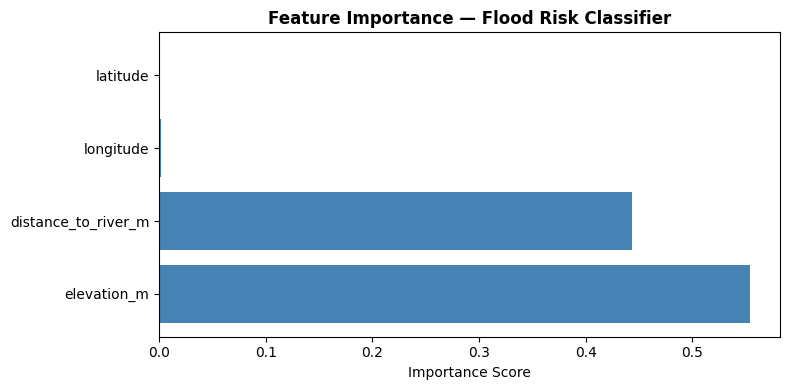

Feature importance plot saved


In [7]:
# Extract and display feature importance
import matplotlib.pyplot as plt

feature_names = features
importances = best_model.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(importance_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_title('Feature Importance — Flood Risk Classifier', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/v1/plots/05_feature_importance.png', dpi=150)
plt.show()
print("Feature importance plot saved")